# Taller 7 - ¿Puede un mapa de calor decirle a la Policía dónde patrullar?

**MIID 4303 - Aprendizaje No Supervisado | Grupo 12**

## Recomendación ejecutiva

Recomendamos que la Policía Metropolitana de Bogotá pruebe un esquema **híbrido y auditable**:

1. **KDE bivariada con ancho de banda seleccionado por `cv_ml`** como capa táctica para localizar concentraciones dentro de los territorios.
2. **Conteos y tasas por unidad territorial** como capa de control, comunicación y seguimiento.
3. Mapas separados para hurto y homicidio: los datos de Chicago muestran que agregarlos oculta patrones distintos.

El mapa de calor **no debe decidir por sí solo** dónde patrullar. Debe generar una lista revisable de microterritorios, ajustada por horario, exposición, capacidad operativa y conocimiento local. La decisión recomendada es un **piloto controlado**, no un despliegue permanente inmediato.

## 0. Trazabilidad con el curso

| Recurso de la semana | Uso en este taller |
|---|---|
| `S7_LSC1_Datos_Geograficos` | `GeoDataFrame`, CRS, proyección, distancia, unión espacial y Folium |
| `S7_LSC2_KDE_2025` | `KernelDensity`, `GridSearchCV`, sesgo-varianza y KDE bivariada |
| `SS_07` | `random_state=123`, `KDEMultivariate`, `normal_reference`, `cv_ml` y datos OSM |
| Semanas 3 y 4 | comparación de modelos, estabilidad, sensibilidad y traducción de resultados a una decisión |

La solución se mantiene en el nivel del curso: `pandas`, `GeoPandas`, `seaborn`, `scikit-learn`, `statsmodels` y `folium`. No se usa un modelo predictivo complejo ni una herramienta que reemplace el razonamiento del equipo.

**Reproducibilidad.** Todos los archivos se leen desde `data/`. Las operaciones aleatorias usan `random_state=123`. La selección de ancho de banda de robos usa una muestra fija para mantener un tiempo de ejecución razonable; el cuaderno documenta el tamaño empleado.

## 1. Preparación del entorno y funciones auxiliares

In [1]:
# Si el entorno no incluye estas librerías, descomente una sola vez:
# %pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels geopandas folium geopy

from pathlib import Path
import json
import warnings

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr, spearmanr
from shapely.geometry import Point
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

RANDOM_STATE = 123
CRS_GEO = "EPSG:4326"
CRS_METRIC = "EPSG:26916"  # NAD83 / UTM 16N: proyección local de Chicago, en metros.

DATA = Path("data")
FIG = Path("figuras")
RES = Path("resultados")
FIG.mkdir(exist_ok=True)
RES.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"robo": "#0f8f8b", "homicidio": "#ef6548"}

def correlaciones(x, y):
    ok = x.notna() & y.notna()
    return {
        "pearson": pearsonr(x[ok], y[ok]).statistic,
        "spearman": spearmanr(x[ok], y[ok]).statistic,
        "n": int(ok.sum()),
    }

def guardar_figura(nombre):
    plt.tight_layout()
    plt.savefig(FIG / nombre, dpi=180, bbox_inches="tight")
    plt.show()

## 2. Paso 1 - Exploración, preparación y unión espacial

In [2]:
delitos = pd.read_csv(DATA / "Chicago_delitos_verano_2019.csv", parse_dates=["fecha"])
delitos["nro_area_comunitaria"] = delitos["nro_area_comunitaria"].astype(int)
delitos = gpd.GeoDataFrame(
    delitos,
    geometry=gpd.points_from_xy(delitos["lon"], delitos["lat"]),
    crs=CRS_GEO,
)

areas = gpd.read_file(f"zip://{(DATA / 'Areas_comunitarias_Chicago.zip').as_posix()}").to_crs(CRS_GEO)
areas["nro_area_comunitaria"] = areas["area_num_1"].astype(int)

union = gpd.sjoin(
    delitos,
    areas[["nro_area_comunitaria", "community", "geometry"]],
    how="left",
    predicate="within",
    lsuffix="dato",
    rsuffix="mapa",
)
union["coincide_id"] = union["nro_area_comunitaria_dato"] == union["nro_area_comunitaria_mapa"]

calidad_union = pd.Series({
    "observaciones": len(union),
    "porcentaje dentro de un polígono": 100 * union["nro_area_comunitaria_mapa"].notna().mean(),
    "porcentaje con ID coincidente": 100 * union["coincide_id"].mean(),
})

display(delitos.head())
display(delitos["tipo_crimen"].value_counts().rename("casos").to_frame())
display(calidad_union.to_frame("resultado"))

,fecha,tipo_crimen,nro_area_comunitaria,lat,lon,geometry
0,2019-06-01 05:07:00+00:00,homicidio,23,41.897950,-87.728625,POINT (-87.72863 41.89795)
1,2019-06-01 10:09:00+00:00,homicidio,71,41.753272,-87.648963,POINT (-87.64896 41.75327)
2,2019-06-01 12:46:00+00:00,homicidio,25,41.877622,-87.750728,POINT (-87.75073 41.87762)
3,2019-06-01 11:35:00+00:00,homicidio,16,41.960145,-87.699654,POINT (-87.69965 41.96015)
4,2019-06-02 09:39:00+00:00,homicidio,37,41.804773,-87.633256,POINT (-87.63326 41.80477)


,casos
tipo_crimen,
robo,17603
homicidio,144


,resultado
observaciones,17747.000000
porcentaje dentro de un polígono,99.594298
porcentaje con ID coincidente,96.934693


In [3]:
# Área: proyectamos antes de medir. En EPSG:26916 las unidades son metros.
areas_metricas = areas.to_crs(CRS_METRIC).copy()
areas_metricas["area_km2"] = areas_metricas.geometry.area / 1_000_000

conteos = (
    delitos.groupby(["nro_area_comunitaria", "tipo_crimen"])
    .size().unstack(fill_value=0).reset_index()
)
conteos["total"] = conteos["robo"] + conteos["homicidio"]

resumen = areas_metricas[["nro_area_comunitaria", "community", "area_km2", "geometry"]].merge(
    conteos, on="nro_area_comunitaria", how="left"
)
resumen[["robo", "homicidio", "total"]] = resumen[["robo", "homicidio", "total"]].fillna(0).astype(int)
for variable in ["robo", "homicidio", "total"]:
    resumen[f"{variable}_por_km2"] = resumen[variable] / resumen["area_km2"]

top_conteo = resumen.nlargest(10, "total")[["nro_area_comunitaria", "community", "robo", "homicidio", "total", "area_km2", "total_por_km2"]]
top_tasa = resumen.nlargest(10, "total_por_km2")[["nro_area_comunitaria", "community", "robo", "homicidio", "total", "area_km2", "total_por_km2"]]

resumen.drop(columns="geometry").to_csv(RES / "tabla_areas_comunitarias.csv", index=False)
display(top_conteo)

,nro_area_comunitaria,community,robo,homicidio,total,area_km2,total_por_km2
37,32,LOOP,1589,0,1589,4.301423,369.412595
36,8,NEAR NORTH SIDE,1559,0,1559,7.118003,219.022094
28,28,NEAR WEST SIDE,912,2,914,14.713428,62.120125
24,24,WEST TOWN,798,1,799,11.842194,67.470605
44,6,LAKE VIEW,762,1,763,8.096437,94.238979
25,25,AUSTIN,671,15,686,18.498320,37.084449
67,7,LINCOLN PARK,522,3,525,8.198679,64.034709
22,22,LOGAN SQUARE,520,0,520,9.288855,55.981066
39,44,CHATHAM,420,4,424,7.641960,55.483146
38,43,SOUTH SHORE,397,6,403,7.594657,53.063618


In [4]:
# Mapa interactivo para identificar las 77 áreas comunitarias.
areas_web = resumen.to_crs(CRS_GEO)
mapa_areas = folium.Map(location=[41.84, -87.68], zoom_start=10, tiles="OpenStreetMap")
folium.GeoJson(
    areas_web,
    name="Áreas comunitarias",
    style_function=lambda _: {"fillColor": "#d9efef", "color": "#17405f", "weight": 1, "fillOpacity": 0.35},
    tooltip=folium.GeoJsonTooltip(
        fields=["nro_area_comunitaria", "community", "total"],
        aliases=["Área", "Nombre", "Delitos"],
    ),
).add_to(mapa_areas)
folium.LayerControl().add_to(mapa_areas)
mapa_areas.save("mapa_interactivo_areas.html")
mapa_areas

### Respuestas del paso 1

**¿Qué tan concentrado está el delito?** El 31,7% de los 17.747 eventos está en cinco áreas y el 46,1% en diez. La concentración es alta, aunque está dominada por los 17.603 robos; solo hay 144 homicidios.

**¿Coinciden las áreas con mayor número de robos y homicidios?** No. Loop y Near North Side lideran robos, pero registran cero homicidios en la ventana. Austin, North Lawndale y Humboldt Park sobresalen en homicidios. Agregar ambos delitos produciría casi el mismo ranking de robos.

**¿Qué decisión induciría un ranking basado únicamente en conteos?** Concentraría patrullaje en Loop, Near North Side, Near West Side, West Town y Lake View. Sería una decisión fácil de explicar, pero trataría el tamaño del área y la exposición como si fueran iguales.

**¿Qué aporta y qué omite este procedimiento?** Aporta estabilidad, trazabilidad y una unidad administrativa clara. Omite variación interna, superficie, población flotante, horario, subregistro y el hecho de que una frontera administrativa no corta el fenómeno delictivo.

**Verificación de la unión.** El 99,59% de los puntos cae dentro de un polígono y el 96,93% coincide además con el identificador reportado. Las discrepancias deben auditarse: pueden ser puntos fronterizos, diferencias de codificación o registros asignados administrativamente a otra zona.

## 3. Paso 2 - Correlación entre robos y homicidios

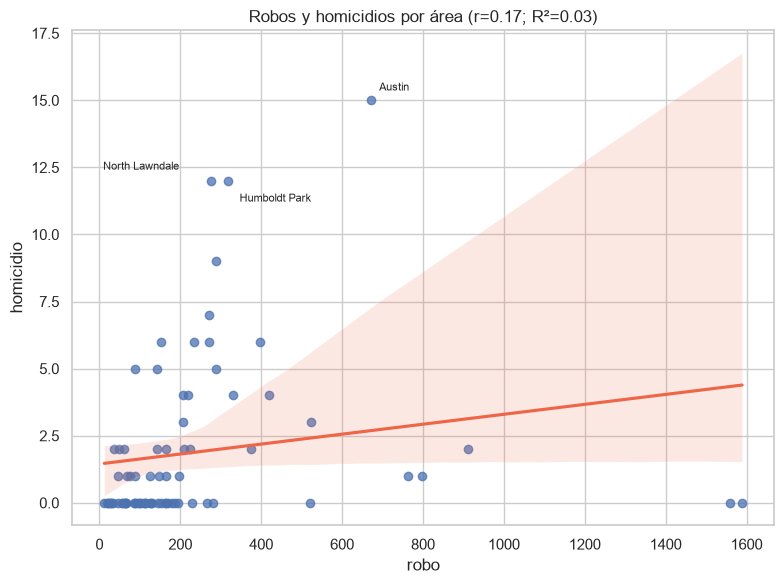

,resultado
pearson,0.171123
spearman,0.464050
n,77.000000
r2,0.029283


,nro_area_comunitaria,community,robo,homicidio,residuo_homicidios
25,25,AUSTIN,671,15,12.310969
29,29,NORTH LAWNDALE,277,12,10.040297
23,23,HUMBOLDT PARK,319,12,9.962551
66,69,GREATER GRAND CROSSING,289,9,7.018084
46,49,ROSELAND,270,7,5.053254


In [5]:
X = resumen[["robo"]].to_numpy()
y = resumen["homicidio"].to_numpy()
modelo_lineal = LinearRegression().fit(X, y)
resumen["residuo_homicidios"] = y - modelo_lineal.predict(X)

corr_delitos = correlaciones(resumen["robo"], resumen["homicidio"])
corr_delitos["r2"] = modelo_lineal.score(X, y)

atipicas = resumen.loc[
    np.argsort(np.abs(resumen["residuo_homicidios"]))[-5:],
    ["nro_area_comunitaria", "community", "robo", "homicidio", "residuo_homicidios", "geometry"],
].sort_values("residuo_homicidios", key=np.abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.regplot(data=resumen, x="robo", y="homicidio", scatter_kws={"alpha": .75}, line_kws={"color": "#ef6548"})
offsets = {"AUSTIN": (6, 7), "NORTH LAWNDALE": (-78, 8), "HUMBOLDT PARK": (8, -15)}
for _, fila in atipicas.head(3).iterrows():
    plt.annotate(
        fila["community"].title(),
        (fila["robo"], fila["homicidio"]),
        xytext=offsets.get(fila["community"], (5, 5)),
        textcoords="offset points",
        fontsize=8,
    )
plt.title(f"Robos y homicidios por área (r={corr_delitos['pearson']:.2f}; R²={corr_delitos['r2']:.2f})")
guardar_figura("01_correlacion_delitos.png")

display(pd.Series(corr_delitos).to_frame("resultado"))
display(atipicas.drop(columns="geometry"))

### Respuestas del paso 2

**¿Qué tan similar es la distribución territorial?** La relación lineal es débil: Pearson = 0,17 y R² = 0,03. Spearman = 0,46 sugiere que parte del orden relativo coincide, pero las magnitudes no. Austin, North Lawndale y Humboldt Park tienen muchos más homicidios de los esperados por su número de robos.

**¿Qué tan sólida es la evidencia para cada delito?** Robos tiene 17.603 observaciones y permite estimaciones más finas. Homicidios tiene 144; su mapa y su ancho de banda son mucho más sensibles a pocos casos. La precisión visual de un mapa no corrige esa diferencia muestral.

**¿Qué implica agregarlos?** El indicador agregado quedaría prácticamente determinado por robos y borraría la señal de violencia letal. Por eso se recomienda modelar y priorizar por separado, aunque luego se coordinen recursos.

## 4. Paso 3 - Conteos frente a normalización por superficie

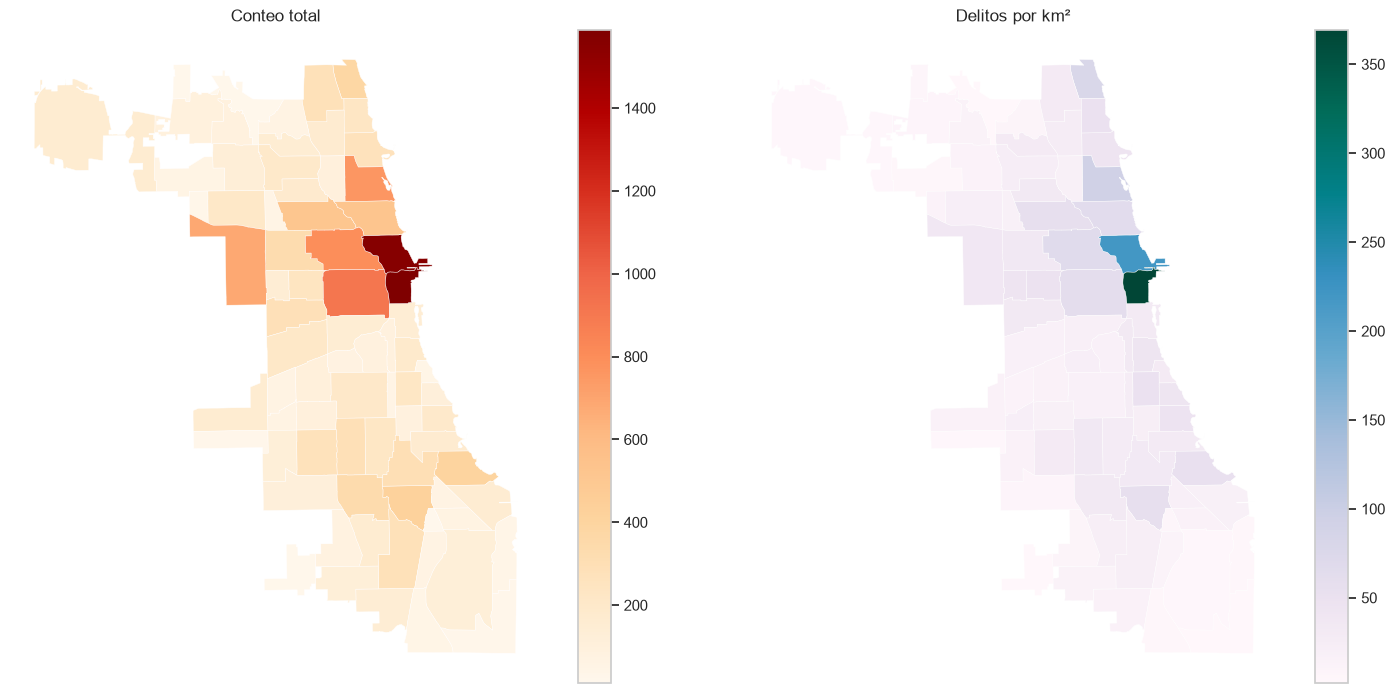

,top_10_conteo,top_10_por_km2
0,LOOP,LOOP
1,NEAR NORTH SIDE,NEAR NORTH SIDE
2,NEAR WEST SIDE,LAKE VIEW
3,WEST TOWN,ROGERS PARK
4,LAKE VIEW,WEST TOWN
5,AUSTIN,LINCOLN PARK
6,LINCOLN PARK,NEAR WEST SIDE
7,LOGAN SQUARE,LOGAN SQUARE
8,CHATHAM,CHATHAM
9,SOUTH SHORE,SOUTH SHORE


Coincidencias en el top 10: 9


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
resumen.plot(column="total", cmap="OrRd", legend=True, ax=axes[0], edgecolor="white", linewidth=.3)
axes[0].set_title("Conteo total")
resumen.plot(column="total_por_km2", cmap="PuBuGn", legend=True, ax=axes[1], edgecolor="white", linewidth=.3)
axes[1].set_title("Delitos por km²")
for ax in axes:
    ax.axis("off")
guardar_figura("02_conteo_vs_densidad_area.png")

comparacion_top = pd.DataFrame({
    "top_10_conteo": top_conteo["community"].reset_index(drop=True),
    "top_10_por_km2": top_tasa["community"].reset_index(drop=True),
})
display(comparacion_top)
print("Coincidencias en el top 10:", len(set(top_conteo.community) & set(top_tasa.community)))

### Respuestas del paso 3

**¿Cambia la identificación de las áreas prioritarias?** Cambia parcialmente: nueve de las diez áreas se mantienen, pero Rogers Park entra al ranking por km². Además cambia el orden; las zonas pequeñas y densas ganan prioridad.

**¿Qué significa normalizar por superficie?** Compara eventos por unidad de espacio. Responde dónde se acumulan más eventos en un territorio compacto, no dónde vive más gente ni dónde hay más víctimas por habitante.

**¿Qué otros denominadores serían relevantes?** Población residente, población flotante, pasajeros, transacciones, establecimientos, horas de apertura, kilómetros de vía y horas de patrullaje. Para hurto, la exposición peatonal/comercial puede ser más adecuada que el área.

**¿Qué tanto depende de las unidades territoriales?** Mucho. El resultado puede cambiar al usar área comunitaria, cuadrante, barrio o grilla; es el problema de la unidad espacial modificable. Conviene repetir el análisis con cuadrantes o microterritorios de Bogotá.

**¿A qué escala permite decidir?** Permite asignar recursos entre áreas, pero no seleccionar una esquina, franja horaria o ruta. Para eso se requiere KDE, temporalidad y una regla operativa posterior.

## 5. Paso 4 - Distancia al centro y KDE univariada

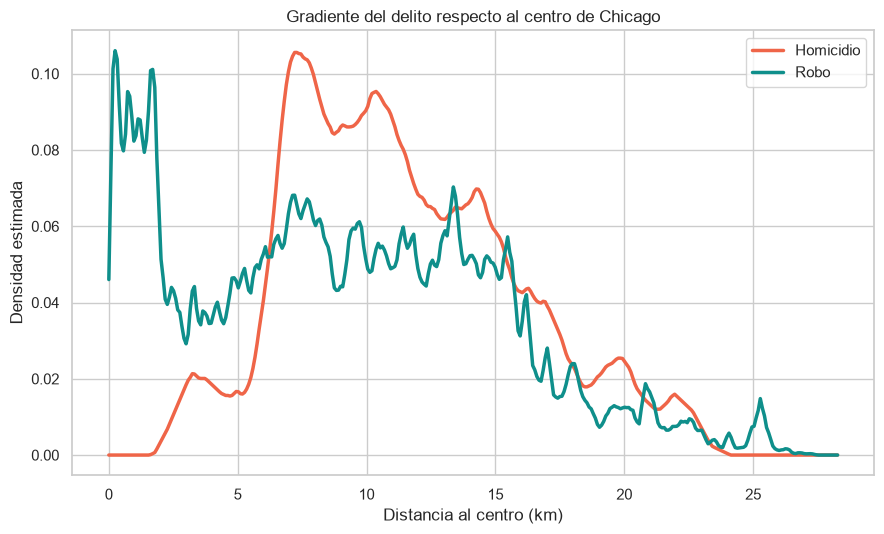

,tipo_crimen,n,n_cv,kernel,bandwidth_km,distancia_mediana_km
0,homicidio,144,144,linear,1.473684,10.717891
1,robo,17603,2500,linear,0.250000,8.635716


In [7]:
delitos_metricos = delitos.to_crs(CRS_METRIC).copy()
centro = gpd.GeoSeries([Point(-87.627800, 41.881998)], crs=CRS_GEO).to_crs(CRS_METRIC).iloc[0]
delitos_metricos["distancia_centro_km"] = delitos_metricos.geometry.distance(centro) / 1000

anchos = np.linspace(0.25, 8.0, 20)
kernels = ["gaussian", "epanechnikov", "tophat", "linear"]
modelos_distancia = []
curvas = []

for tipo, grupo in delitos_metricos.groupby("tipo_crimen"):
    valores = grupo[["distancia_centro_km"]].to_numpy()
    n_cv = min(len(valores), 2500)
    muestra = grupo.sample(n_cv, random_state=RANDOM_STATE)[["distancia_centro_km"]].to_numpy()
    busqueda = GridSearchCV(KernelDensity(), {"bandwidth": anchos, "kernel": kernels}, cv=5)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        busqueda.fit(muestra)
    mejor = busqueda.best_params_
    modelo = KernelDensity(**mejor).fit(valores)
    grilla = np.linspace(0, delitos_metricos["distancia_centro_km"].max() + 1, 350)[:, None]
    densidad = np.exp(modelo.score_samples(grilla))
    curvas.append(pd.DataFrame({"distancia_centro_km": grilla[:, 0], "densidad": densidad, "tipo_crimen": tipo}))
    modelos_distancia.append({
        "tipo_crimen": tipo, "n": len(valores), "n_cv": n_cv,
        "kernel": mejor["kernel"], "bandwidth_km": mejor["bandwidth"],
        "distancia_mediana_km": np.median(valores),
    })

modelos_distancia = pd.DataFrame(modelos_distancia)
curvas = pd.concat(curvas, ignore_index=True)

plt.figure(figsize=(9, 5.5))
for tipo, grupo in curvas.groupby("tipo_crimen"):
    plt.plot(grupo["distancia_centro_km"], grupo["densidad"], label=tipo.title(), color=COLORS[tipo], linewidth=2.5)
plt.xlabel("Distancia al centro (km)")
plt.ylabel("Densidad estimada")
plt.title("Gradiente del delito respecto al centro de Chicago")
plt.legend()
guardar_figura("03_kde_distancia_centro.png")
display(modelos_distancia)

### Respuestas del paso 4

**¿Cómo se midieron las distancias?** Se proyectaron puntos y centro a NAD83 / UTM 16N (`EPSG:26916`) y se usó distancia euclidiana, expresada en kilómetros. En esta escala urbana evita tratar grados como kilómetros.

**¿Qué kernel y ancho selecciona la validación cruzada?** Kernel lineal para ambos delitos; 0,25 km para robos y 1,47 km para homicidios. La muestra de CV de robos fue de 2.500 casos con semilla 123; homicidios usó los 144 casos.

**¿Qué tan sensibles son los resultados?** Bastante al ancho de banda: el valor pequeño de robos conserva variación local, mientras homicidios requiere más suavizado por la escasez. La elección de kernel fue menos determinante que el ancho, coherente con el curso.

**¿Se comporta igual para robos y homicidios?** No. La distancia mediana es 8,64 km para robos y 10,72 km para homicidios, y las curvas presentan modos distintos.

**¿Qué supuestos espaciales implica?** Reduce la ciudad a anillos alrededor de un único centro: dos puntos a igual distancia se consideran equivalentes aunque estén en direcciones y contextos distintos.

**¿Qué utilidad operativa tiene?** Es un diagnóstico del gradiente centro-periferia, no una regla de patrullaje. No identifica calles ni zonas bidimensionales concretas, por lo cual ocupa el último lugar del ranking.

## 6. Paso 5 - Puntos calientes en el plano con `statsmodels`

In [8]:
def seleccionar_picos(xx, yy, densidad, metodo, tipo, distancia_minima_km=3, n=5):
    orden = np.argsort(densidad)[::-1]
    elegidos = []
    for indice in orden:
        candidato = np.array([xx.ravel()[indice], yy.ravel()[indice]])
        if all(np.linalg.norm(candidato - previo) >= distancia_minima_km for previo in elegidos):
            elegidos.append(candidato)
        if len(elegidos) == n:
            break
    return gpd.GeoDataFrame(
        {"modelo": metodo, "tipo_crimen": tipo, "ranking": range(1, len(elegidos) + 1)},
        geometry=[Point(p[0] * 1000, p[1] * 1000) for p in elegidos], crs=CRS_METRIC,
    )

grilla_x_m = np.linspace(resumen.total_bounds[0], resumen.total_bounds[2], 105)
grilla_y_m = np.linspace(resumen.total_bounds[1], resumen.total_bounds[3], 105)
xx_m, yy_m = np.meshgrid(grilla_x_m, grilla_y_m)
xx, yy = xx_m / 1000, yy_m / 1000
grilla_pred = np.column_stack([yy.ravel(), xx.ravel()])
grilla_geo = gpd.GeoDataFrame(geometry=gpd.points_from_xy(xx_m.ravel(), yy_m.ravel()), crs=CRS_METRIC)
dentro = grilla_geo.geometry.within(resumen.geometry.union_all()).to_numpy()

modelos_kde = []
superficies = {}
picos = []

for tipo in ["robo", "homicidio"]:
    grupo = delitos_metricos.loc[delitos_metricos.tipo_crimen == tipo].copy()
    grupo["x_km"] = grupo.geometry.x / 1000
    grupo["y_km"] = grupo.geometry.y / 1000
    n_ajuste = min(len(grupo), 600 if tipo == "robo" else len(grupo))
    muestra = grupo.sample(n_ajuste, random_state=RANDOM_STATE)
    datos_xy = muestra[["y_km", "x_km"]].to_numpy()
    for metodo in ["normal_reference", "cv_ml"]:
        modelo = sm.nonparametric.KDEMultivariate(data=datos_xy, var_type="cc", bw=metodo)
        densidad = np.asarray(modelo.pdf(data_predict=grilla_pred), dtype=float)
        densidad[~dentro] = np.nan
        superficies[f"{tipo}_{metodo}"] = densidad
        modelos_kde.append({
            "tipo_crimen": tipo, "metodo": metodo, "n_total": len(grupo), "n_ajuste": n_ajuste,
            "bw_y_km": modelo.bw[0], "bw_x_km": modelo.bw[1],
        })
        picos.append(seleccionar_picos(xx, yy, np.where(np.isnan(densidad), -np.inf, densidad), metodo, tipo))

modelos_kde = pd.DataFrame(modelos_kde)
picos = pd.concat(picos, ignore_index=True)
picos_area = gpd.sjoin(picos, resumen[["nro_area_comunitaria", "community", "geometry"]], how="left", predicate="within")
display(modelos_kde)
display(picos_area.drop(columns=["geometry", "index_right"]))

C:\Users\harol\OneDrive\Documentos\GitHub\MIID-4303-Aprendizaje-No-Supervisado-G12\tmp\semana7_packages\pandas\util\_decorators.py:220: FutureWarning: After 0.17 or January 2028, whichever comes first, the default behavior will switch to using an entropy initialized numpy.random.Generator.
  return func(*args, **kwargs)


C:\Users\harol\OneDrive\Documentos\GitHub\MIID-4303-Aprendizaje-No-Supervisado-G12\tmp\semana7_packages\pandas\util\_decorators.py:220: FutureWarning: After 0.17 or January 2028, whichever comes first, the default behavior will switch to using an entropy initialized numpy.random.Generator.
  return func(*args, **kwargs)


C:\Users\harol\OneDrive\Documentos\GitHub\MIID-4303-Aprendizaje-No-Supervisado-G12\tmp\semana7_packages\statsmodels\nonparametric\kernel_density.py:221: RuntimeWarning: invalid value encountered in log
  L += func(f_i)


C:\Users\harol\OneDrive\Documentos\GitHub\MIID-4303-Aprendizaje-No-Supervisado-G12\tmp\semana7_packages\pandas\util\_decorators.py:220: FutureWarning: After 0.17 or January 2028, whichever comes first, the default behavior will switch to using an entropy initialized numpy.random.Generator.
  return func(*args, **kwargs)


C:\Users\harol\OneDrive\Documentos\GitHub\MIID-4303-Aprendizaje-No-Supervisado-G12\tmp\semana7_packages\pandas\util\_decorators.py:220: FutureWarning: After 0.17 or January 2028, whichever comes first, the default behavior will switch to using an entropy initialized numpy.random.Generator.
  return func(*args, **kwargs)


,tipo_crimen,metodo,n_total,n_ajuste,bw_y_km,bw_x_km
0,robo,normal_reference,17603,600,3.202005,1.615298
1,robo,cv_ml,17603,600,1.274507,0.606102
2,homicidio,normal_reference,144,144,3.749950,2.312857
3,homicidio,cv_ml,144,144,1.562316,0.873893


,modelo,tipo_crimen,ranking,nro_area_comunitaria,community
0,normal_reference,robo,1,8,NEAR NORTH SIDE
1,normal_reference,robo,2,7,LINCOLN PARK
2,normal_reference,robo,3,33,NEAR SOUTH SIDE
3,normal_reference,robo,4,6,LAKE VIEW
4,normal_reference,robo,5,24,WEST TOWN
5,cv_ml,robo,1,8,NEAR NORTH SIDE
6,cv_ml,robo,2,6,LAKE VIEW
7,cv_ml,robo,3,28,NEAR WEST SIDE
8,cv_ml,robo,4,7,LINCOLN PARK
9,cv_ml,robo,5,24,WEST TOWN


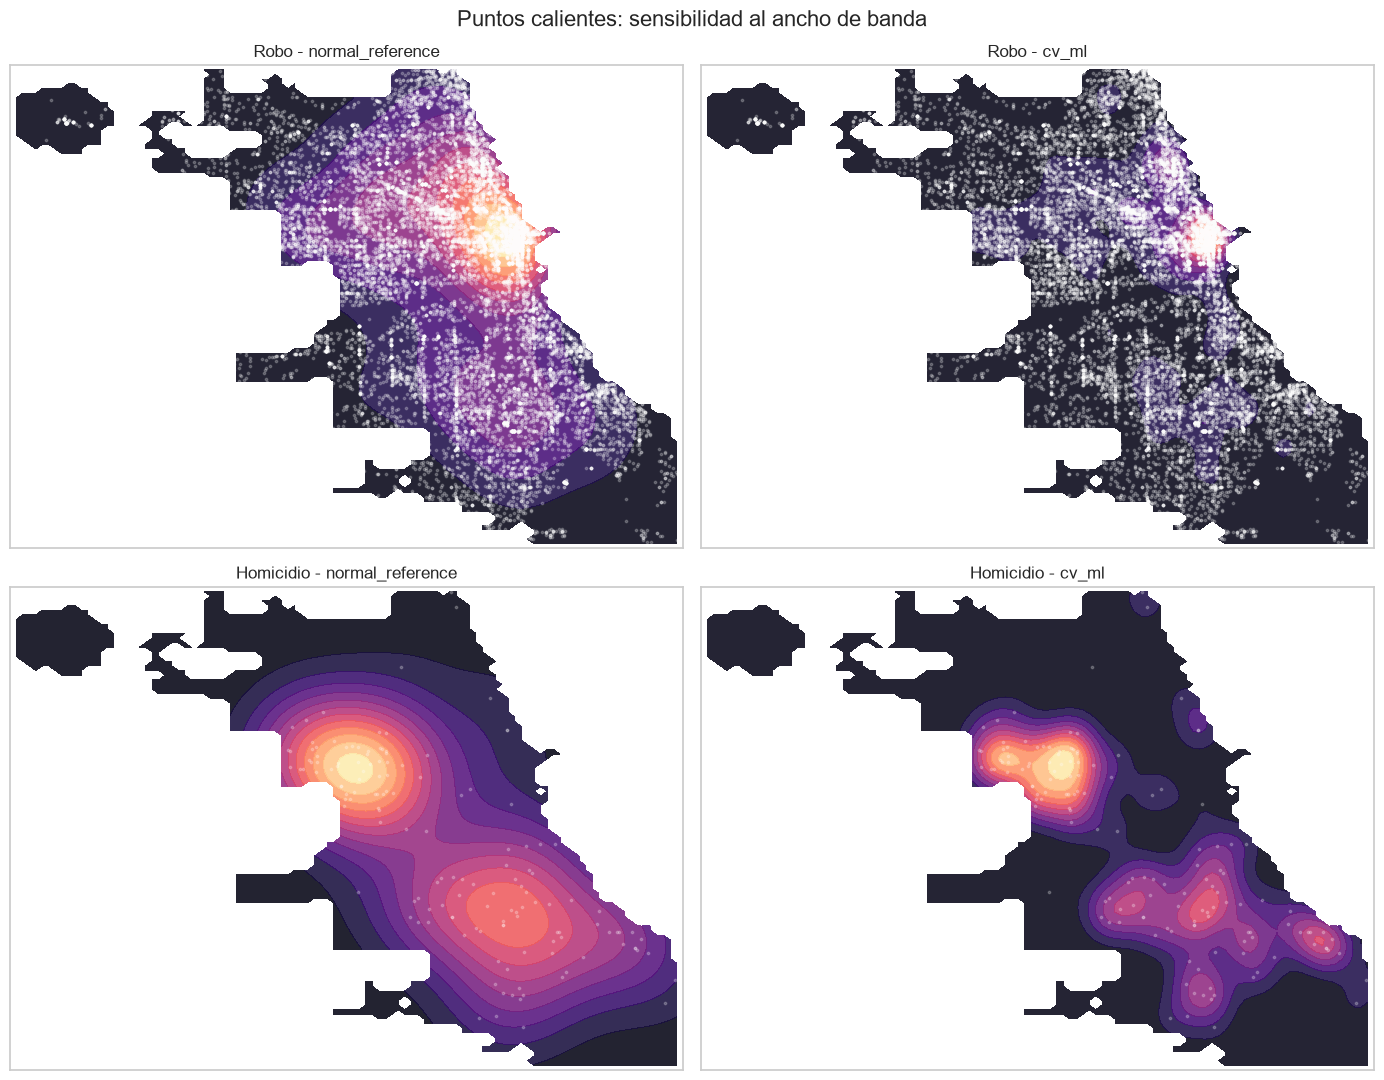

,tipo_crimen,Jaccard,normal_reference,cv_ml
0,robo,0.666667,"[LAKE VIEW, LINCOLN PARK, NEAR NORTH SIDE, NEA...","[LAKE VIEW, LINCOLN PARK, NEAR NORTH SIDE, NEA..."
1,homicidio,0.250000,"[GREATER GRAND CROSSING, HUMBOLDT PARK, NORTH ...","[AUSTIN, EAST GARFIELD PARK, GREATER GRAND CRO..."


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, tipo, metodo in [
    (axes[0, 0], "robo", "normal_reference"),
    (axes[0, 1], "robo", "cv_ml"),
    (axes[1, 0], "homicidio", "normal_reference"),
    (axes[1, 1], "homicidio", "cv_ml"),
]:
    superficie = superficies[f"{tipo}_{metodo}"].reshape(xx.shape)
    ax.contourf(xx, yy, superficie, levels=12, cmap="magma", alpha=.88)
    pts = delitos_metricos.loc[delitos_metricos.tipo_crimen == tipo]
    ax.scatter(pts.geometry.x / 1000, pts.geometry.y / 1000, s=3, color="white", alpha=.22)
    ax.set_title(f"{tipo.title()} - {metodo}")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Puntos calientes: sensibilidad al ancho de banda", fontsize=16)
guardar_figura("04_kde_bivariada_comparacion.png")

estabilidad = []
for tipo in ["robo", "homicidio"]:
    normal = set(picos_area.loc[(picos_area.tipo_crimen == tipo) & (picos_area.modelo == "normal_reference"), "community"].dropna())
    cv = set(picos_area.loc[(picos_area.tipo_crimen == tipo) & (picos_area.modelo == "cv_ml"), "community"].dropna())
    estabilidad.append({"tipo_crimen": tipo, "Jaccard": len(normal & cv) / len(normal | cv), "normal_reference": sorted(normal), "cv_ml": sorted(cv)})
display(pd.DataFrame(estabilidad))

### Respuestas del paso 5

**¿Qué ancho produce cada método y qué escala representa?** Para robos, `normal_reference` produce aproximadamente 3,20 km norte-sur y 1,62 km este-oeste; `cv_ml`, 1,27 y 0,61 km. Para homicidios son 3,75/2,31 km y 1,56/0,87 km. `cv_ml` representa una escala más local y revela más subzonas.

**¿Qué tan diferentes son los puntos calientes?** En robos, cuatro de cinco zonas generales se conservan; Jaccard = 0,67. En homicidios, el acuerdo baja a 0,25: la muestra pequeña hace que el mapa sea inestable.

**¿Cómo cambia el resultado al modificar el suavizamiento?** `normal_reference` fusiona eventos cercanos en regiones amplias; `cv_ml` separa picos y entrega más detalle. Más detalle no significa automáticamente más verdad: también aumenta la sensibilidad al ruido.

**¿Qué tan estable es la identificación?** Razonablemente estable para robos y débil para homicidios. Por eso una zona de homicidio debería entrar al plan solo si persiste entre ventanas temporales o métodos, no por aparecer una vez.

**¿Cómo se pasa de superficie continua a lugares concretos?** Se seleccionan máximos locales separados al menos 3 km, se asignan al área comunitaria que los contiene y se convierten en candidatos, no en órdenes automáticas.

**¿Qué decisiones adicionales se requieren?** Definir número de patrullas, radio, horarios, duración, criterio de persistencia, capacidad de respuesta, restricciones de movilidad, revisión por mandos locales y mecanismo para retirar zonas del listado.

## 7. Paso 6 - Actividad comercial de OpenStreetMap

In [10]:
# La descarga se conserva para reproducibilidad. Es una instantánea de OSM consultada en 2026,
# por lo que se interpreta como proxy de actividad comercial, no como medición contemporánea al delito de 2019.
osm_payload = json.loads((DATA / "osm_actividad_comercial_chicago.json").read_text(encoding="utf-8"))
filas = []
for elemento in osm_payload.get("elements", []):
    lat = elemento.get("lat", elemento.get("center", {}).get("lat"))
    lon = elemento.get("lon", elemento.get("center", {}).get("lon"))
    if lat is None or lon is None:
        continue
    tags = elemento.get("tags", {})
    categoria = "landuse" if tags.get("landuse") in {"commercial", "retail"} else ("shop" if "shop" in tags else "amenity")
    filas.append({"osm_id": f"{elemento.get('type')}/{elemento.get('id')}", "lat": lat, "lon": lon, "categoria": categoria})

osm = pd.DataFrame(filas).drop_duplicates("osm_id")
osm = gpd.GeoDataFrame(osm, geometry=gpd.points_from_xy(osm.lon, osm.lat), crs=CRS_GEO)
osm_union = gpd.sjoin(osm, areas[["nro_area_comunitaria", "geometry"]], how="inner", predicate="within")
osm_conteos = osm_union.groupby(["nro_area_comunitaria", "categoria"]).size().unstack(fill_value=0).reset_index()
osm_conteos["actividad_comercial_osm"] = osm_conteos.drop(columns="nro_area_comunitaria").sum(axis=1)

resumen_osm = resumen.merge(osm_conteos, on="nro_area_comunitaria", how="left")
resumen_osm["actividad_comercial_osm"] = resumen_osm["actividad_comercial_osm"].fillna(0)
resumen_osm["actividad_comercial_por_km2"] = resumen_osm["actividad_comercial_osm"] / resumen_osm["area_km2"]

corr_osm = pd.DataFrame({
    "robos_conteo": correlaciones(resumen_osm["actividad_comercial_osm"], resumen_osm["robo"]),
    "homicidios_conteo": correlaciones(resumen_osm["actividad_comercial_osm"], resumen_osm["homicidio"]),
    "robos_por_km2": correlaciones(resumen_osm["actividad_comercial_por_km2"], resumen_osm["robo_por_km2"]),
    "homicidios_por_km2": correlaciones(resumen_osm["actividad_comercial_por_km2"], resumen_osm["homicidio_por_km2"]),
}).T
display(corr_osm)

,pearson,spearman,n
robos_conteo,0.844415,0.586014,77.0
homicidios_conteo,-0.116323,-0.105240,77.0
robos_por_km2,0.861287,0.553000,77.0
homicidios_por_km2,-0.213804,-0.184379,77.0


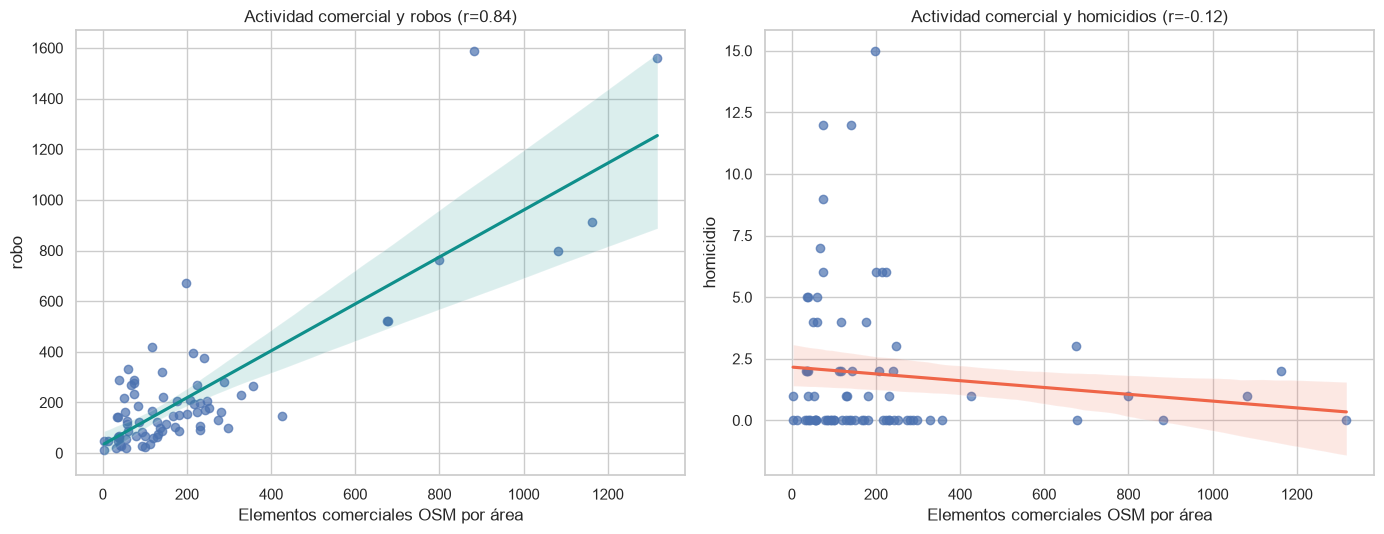

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.regplot(data=resumen_osm, x="actividad_comercial_osm", y="robo", ax=axes[0], scatter_kws={"alpha": .7}, line_kws={"color": COLORS["robo"]})
axes[0].set_title(f"Actividad comercial y robos (r={corr_osm.loc['robos_conteo', 'pearson']:.2f})")
sns.regplot(data=resumen_osm, x="actividad_comercial_osm", y="homicidio", ax=axes[1], scatter_kws={"alpha": .7}, line_kws={"color": COLORS["homicidio"]})
axes[1].set_title(f"Actividad comercial y homicidios (r={corr_osm.loc['homicidios_conteo', 'pearson']:.2f})")
for ax in axes:
    ax.set_xlabel("Elementos comerciales OSM por área")
guardar_figura("05_osm_comercio_correlaciones.png")

### Respuestas del paso 6

**¿Son similares las correlaciones para ambos delitos?** No. La actividad comercial OSM se asocia fuertemente con robos (Pearson = 0,84 en conteos y 0,86 por km²), pero no con homicidios (−0,12 y −0,21).

**¿Qué explicaciones son consistentes con el patrón?** Más actividad comercial implica más personas, transacciones, bienes expuestos y oportunidades de reporte de robos. Los homicidios pueden estar más relacionados con conflictos, mercados ilegales, armas y dinámicas residenciales que el proxy comercial no mide.

**¿Hasta dónde puede interpretarse?** Como asociación espacial exploratoria. OSM tiene cobertura desigual, mezcla puntos y polígonos, y la instantánea es de 2026 mientras los delitos son de 2019. No permite afirmar que el comercio cause robos ni que patrullar comercios reduzca el delito.

**¿Qué evidencia adicional se necesita?** Exposición horaria, población flotante, transporte, llamadas al servicio, cámaras, victimización, cierres comerciales, datos históricos de OSM y una evaluación causal del despliegue policial.

## 8. Paso 7 - Ranking, transferencia y recomendación

In [12]:
ranking = pd.DataFrame([
    ["KDE 2D cv_ml", 5, 3, 3, 5, 3],
    ["KDE 2D normal_reference", 4, 3, 4, 4, 3],
    ["Conteo por área", 2, 2, 5, 4, 5],
    ["Tasa por km²", 2, 4, 4, 3, 4],
    ["Distancia al centro", 1, 3, 3, 1, 3],
], columns=["procedimiento", "granularidad", "comparabilidad", "estabilidad", "utilidad_operativa", "transparencia"])

pesos = {"granularidad": .20, "comparabilidad": .15, "estabilidad": .25, "utilidad_operativa": .30, "transparencia": .10}
ranking["puntaje"] = sum(ranking[criterio] * peso for criterio, peso in pesos.items())
ranking = ranking.sort_values("puntaje", ascending=False).reset_index(drop=True)
ranking.insert(0, "ranking", range(1, len(ranking) + 1))
ranking.to_csv(RES / "ranking_procedimientos.csv", index=False)
display(ranking.style.format({"puntaje": "{:.2f}"}))

,ranking,procedimiento,granularidad,comparabilidad,estabilidad,utilidad_operativa,transparencia,puntaje
0,1,KDE 2D cv_ml,5,3,3,5,3,4.00
1,2,KDE 2D normal_reference,4,3,4,4,3,3.75
2,3,Conteo por área,2,2,5,4,5,3.65
3,4,Tasa por km²,2,4,4,3,4,3.30
4,5,Distancia al centro,1,3,3,1,3,2.00


### Respuestas del paso 7

**¿Qué procedimiento recomendamos y por qué?** KDE 2D con `cv_ml` como capa táctica, acompañado por conteos y tasas territoriales. Es el método que mejor ubica concentraciones internas y se ajusta a la decisión de patrullaje; la capa territorial permite auditarlo y comunicarlo.

**¿Qué ventajas y limitaciones tiene?** Ventajas: continuidad espacial, detalle y ausencia de dependencia estricta de fronteras. Limitaciones: sensibilidad al ancho de banda, costo computacional, dificultad de explicar la escala y riesgo de confundir registros policiales con riesgo real.

**¿Qué trade-offs implica?** Precisión local frente a estabilidad; detalle frente a interpretabilidad; reacción a patrones recientes frente a riesgo de perseguir ruido; eficiencia frente a equidad y desplazamiento.

**¿Qué resguardos y controles se necesitan?** Separar delitos, exigir persistencia en dos ventanas o métodos, limitar uso de datos personales, auditar sesgo de denuncia/control, revisión humana, publicar criterios, registrar cambios de patrullaje, vigilar desplazamiento, quejas y contactos policiales.

**¿Cómo evaluar el desempeño?** Piloto de 8 a 12 semanas en microterritorios comparables, asignación aleatoria o implementación escalonada, línea base previa y métricas de delitos, victimización, tiempos de respuesta, delitos por hora-patrulla, desplazamiento a zonas vecinas, quejas y distribución de controles.

**¿Qué decisión concreta debe tomar el cliente?** Autorizar un piloto limitado de KDE para **hurto y homicidio por separado**, usando cuadrantes o microterritorios de Bogotá, con actualización semanal, revisión operativa y evaluación independiente antes de escalar.

## 9. ¿Qué se puede transferir de Chicago a Bogotá?

### Generalizable entre ciudades

- El flujo: validar coordenadas y CRS, separar delitos, comparar conteos/tasas/KDE, probar sensibilidad y convertir la superficie en una regla explícita.
- El principio de usar un CRS métrico local y seleccionar el ancho de banda con datos.
- La necesidad de combinar precisión táctica, estabilidad, transparencia, factibilidad y equidad.
- La evaluación mediante piloto y grupo de comparación.

### Dependiente del contexto de Chicago

- Los anchos de banda, puntos calientes, áreas prioritarias y asociación cuantitativa con comercio.
- La geometría de las 77 áreas comunitarias, el centro usado y la estructura vial.
- La mezcla 2019 de 17.603 robos frente a 144 homicidios y el patrón de denuncia.

### Adaptación concreta a Bogotá

El resultado encaja con el **Modelo del Servicio de Policía Orientado a las Personas y los Territorios**, que trabaja con comprensión territorial, focalización y microterritorios. Para el piloto se debe reemplazar las áreas de Chicago por cuadrantes/microterritorios de Bogotá, usar MAGNA-SIRGAS apropiado para medir, incorporar población flotante y flujos comerciales, y validar con mandos y comunidad.

La base oficial de cuadrantes describe unidades geográficas cuya atención se ajusta a características delictivas, sociales, demográficas, geográficas y económicas; por eso es una escala de control más pertinente que copiar áreas comunitarias de Chicago.

## 10. Respuesta final al cliente

**¿Puede un mapa de calor decirle a la Policía dónde patrullar?** Puede ayudar a producir una lista inicial de zonas y horarios, pero no debe tomar la decisión. En este ejercicio, KDE encuentra estructuras que los conteos por área ocultan, pero la elección del ancho de banda cambia los resultados y la inestabilidad es alta para homicidios.

La recomendación es usarlo como **instrumento de focalización revisable** dentro de un piloto: KDE `cv_ml` para localizar, `normal_reference` y rankings territoriales para comprobar estabilidad, conocimiento local para revisar factibilidad y una evaluación experimental para saber si el patrullaje realmente reduce daño sin desplazarlo ni aumentar controles injustificados.

### Fuentes y alcance

- Material del curso: `S7_LSC1_Datos_Geograficos`, `S7_LSC2_KDE_2025` y `SS_07`.
- Guía del taller: *¿Puede un mapa de calor decirle a la policía dónde patrullar?*
- [Modelo del Servicio de Policía Orientado a las Personas y los Territorios](https://www.policia.gov.co/modelo-del-servicio-policia).
- [Cuadrantes de Policía - Datos Abiertos Bogotá](https://datosabiertos.bogota.gov.co/en/dataset/cuadrantes-de-policia-bogota-d-c).
- OpenStreetMap: © colaboradores de OpenStreetMap. Consulta conservada en `data/osm_actividad_comercial_chicago.json`.

**Límite principal:** este análisis identifica asociaciones y prioridades metodológicas; no demuestra que el despliegue policial cause una reducción del delito.